# Machine Failure Prediction with Automated Drift Monitoring
## Phase 4 — Notebook 04: Baseline Model Benchmarking & Feature Set Impact

### 1. Title & Project Context
**Project**: Machine Failure Prediction with Automated Drift Monitoring  
**Dataset**: AI4I 2020 Predictive Maintenance Dataset (`data/raw/ai4i2020.csv`)  
**Phase**: Phase 4 — Baseline Model Benchmarking  

#### Core Objectives of Phase 4
In Phase 2, we established a leakage-safe **70% Train / 15% Validation / 15% Test** partition protocol with zero sample overlap. In Phase 3, we engineered three physically grounded domain features:
- Temperature differential: $\Delta T = T_{\text{process}} - T_{\text{air}}$ [K]
- Mechanical power: $\text{Power} = \tau \cdot \omega \cdot \frac{2\pi}{60}$ [W]
- Tool overstrain load: $\text{WearLoad} = \text{Tool wear} \times \text{Torque}$ [min$\cdot$Nm]

The purpose of Phase 4 is to establish rigorous, empirical baseline performance benchmarks across diverse model families and validate the impact of domain feature engineering:
1. **Model Diversity**: Train four foundational classification architectures spanning linear and tree-based paradigms:
   - **Logistic Regression** (L2-regularized linear baseline)
   - **Random Forest** (Bagged ensemble of decision trees)
   - **XGBoost** (Extreme Gradient Boosted trees)
   - **LightGBM** (Light Gradient Boosted Machine with leaf-wise expansion)
2. **Critical Feature Comparison**:
   - **Raw Feature Set**: 6 input features ($5$ sensor features standardized + $1$ categorical variant one-hot encoded $\rightarrow 8$ columns).
   - **Engineered Feature Set**: 9 input features (Raw + $\Delta T$ + $\text{Power}$ + $\text{WearLoad}$ standardized $\rightarrow 11$ columns).
3. **Validation Set Evaluation**:
   - **Primary Metric**: **PR-AUC (Average Precision)** — essential for evaluating positive-class discrimination under severe $28.5 : 1$ class imbalance.
   - **Secondary Metrics**: **ROC-AUC**, **Precision**, **Recall**, **F1-Score**, and **Confusion Matrix counts**.
4. **Test Set Quarantine**:
   - The test set ($1,500$ observations, $51$ failures) remains strictly untouched and sealed in this notebook.

#### Phase 4 Boundaries
- **No Hyperparameter Optimization**: All models use default configurations with class-imbalance weighting.
- **No Probability Calibration or Conformal Prediction**: Addressed in later phases.
- **No Threshold Optimization**: Standard decision threshold ($0.5$) is evaluated; threshold tuning is deferred.
- **Raw CSV Integrity**: `data/raw/ai4i2020.csv` remains completely unmodified.


### 2. Setup & Imports
We import standard numerical libraries, scikit-learn model families, gradient boosting frameworks (`xgboost`, `lightgbm`), evaluation metrics, and configuration loaders.


In [1]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 13

pd.set_option('display.max_columns', 25)
pd.set_option('display.precision', 4)

print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print("Baseline benchmarking environment successfully initialized.")


XGBoost version: 3.4.1
LightGBM version: 4.7.0
Baseline benchmarking environment successfully initialized.


**Observation**:
Environment is initialized with XGBoost 3.4.1 and LightGBM 4.7.0. Clean plotting defaults are set for comparative PR and ROC curve visualizations.


### 3. Load Dataset & Construct Leakage-Safe Feature Partitions
We load the raw dataset and reproduce the Phase 2 stratified split ($7,000$ Train / $1,500$ Validation / $1,500$ Test). We construct both the **Raw** feature matrix and the **Engineered** feature matrix, fitting preprocessor scalers strictly on `X_train`.


In [2]:
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

raw_data_path = os.path.join('..', config['data']['raw_data_path'])
target_col = config['data']['target_column']
random_seed = config['project']['random_seed']

df = pd.read_csv(raw_data_path)

# Intended operational features
intended_features = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df[intended_features].copy()
y = df[target_col].copy()

# Step 1: Stratified split into 70% Train, 30% Temp Holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=random_seed, stratify=y
)
# Step 2: Stratified split into 15% Validation, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=random_seed, stratify=y_temp
)

# Domain Feature Extraction Function
def add_domain_features(data):
    out = data.copy()
    out['Temp_Diff'] = out['Process temperature [K]'] - out['Air temperature [K]']
    out['Power'] = out['Torque [Nm]'] * out['Rotational speed [rpm]'] * (2 * np.pi / 60)
    out['Wear_Load'] = out['Tool wear [min]'] * out['Torque [Nm]']
    return out

X_train_eng = add_domain_features(X_train)
X_val_eng = add_domain_features(X_val)

# Preprocessing Pipelines
raw_num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
eng_num_cols = raw_num_cols + ['Temp_Diff', 'Power', 'Wear_Load']
cat_cols = ['Type']

preprocessor_raw = ColumnTransformer([
    ('num', StandardScaler(), raw_num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

preprocessor_eng = ColumnTransformer([
    ('num', StandardScaler(), eng_num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Strict Leakage Rule: Fit ONLY on X_train
X_train_raw_proc = preprocessor_raw.fit_transform(X_train)
X_val_raw_proc = preprocessor_raw.transform(X_val)

X_train_eng_proc = preprocessor_eng.fit_transform(X_train_eng)
X_val_eng_proc = preprocessor_eng.transform(X_val_eng)

raw_feature_names = list(preprocessor_raw.get_feature_names_out())
eng_feature_names = list(preprocessor_eng.get_feature_names_out())

print(f"X_train_raw_proc Shape: {X_train_raw_proc.shape} ({len(raw_feature_names)} features)")
print(f"X_val_raw_proc Shape:   {X_val_raw_proc.shape}")
print(f"\nX_train_eng_proc Shape: {X_train_eng_proc.shape} ({len(eng_feature_names)} features)")
print(f"X_val_eng_proc Shape:   {X_val_eng_proc.shape}")
print(f"\nTest set status: QUARANTINED ({X_test.shape[0]} samples, {y_test.sum()} failures untouched)")


X_train_raw_proc Shape: (7000, 8) (8 features)
X_val_raw_proc Shape:   (1500, 8)

X_train_eng_proc Shape: (7000, 11) (11 features)
X_val_eng_proc Shape:   (1500, 11)

Test set status: QUARANTINED (1500 samples, 51 failures untouched)


**Observation**:
The data partitions are prepared. The raw feature set yields 8 encoded dimensions; the domain-engineered feature set expands to 11 dimensions. The test set remains completely unreferenced.


### 4. Class Imbalance Handling Strategy
In the training partition:
- Negative instances (`0`): **6,763**
- Positive instances (`1`): **237**
- Imbalance Ratio:
  $$\text{Imbalance Ratio} = \frac{6,763}{237} = 28.5359 : 1$$

Without imbalance correction, models can achieve high accuracy by predicting normal operation for nearly all cases. To ensure fair baseline comparison without data fabrication:
- **Logistic Regression**: `class_weight='balanced'`
- **Random Forest**: `class_weight='balanced'`
- **XGBoost**: `scale_pos_weight = 6763 / 237 = 28.5359`
- **LightGBM**: `scale_pos_weight = 6763 / 237 = 28.5359`

This inversely scales the loss gradient for positive failure instances, compelling each algorithm to prioritize minority class detection.


In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Training negative samples (0): {(y_train == 0).sum():,}")
print(f"Training positive samples (1): {(y_train == 1).sum():,}")
print(f"Calculated scale_pos_weight:   {scale_pos_weight:.4f}")


Training negative samples (0): 6,763
Training positive samples (1): 237
Calculated scale_pos_weight:   28.5359


### 5. Model Training & Validation Benchmarking
We instantiate and train all 4 baseline classifiers across both feature spaces:
- 4 Architectures $\times$ 2 Feature Sets = **8 Model Configurations**.
- All models are evaluated on `X_val` ($N = 1,500$, $51$ failures).


In [4]:
models_to_benchmark = {
    'Logistic Regression': {
        'Raw': LogisticRegression(class_weight='balanced', random_state=random_seed, max_iter=1000),
        'Engineered': LogisticRegression(class_weight='balanced', random_state=random_seed, max_iter=1000)
    },
    'Random Forest': {
        'Raw': RandomForestClassifier(class_weight='balanced', random_state=random_seed, n_estimators=100),
        'Engineered': RandomForestClassifier(class_weight='balanced', random_state=random_seed, n_estimators=100)
    },
    'XGBoost': {
        'Raw': xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=random_seed, eval_metric='logloss'),
        'Engineered': xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=random_seed, eval_metric='logloss')
    },
    'LightGBM': {
        'Raw': lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=random_seed, verbose=-1),
        'Engineered': lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=random_seed, verbose=-1)
    }
}

benchmark_results = []
trained_models = {}
validation_probabilities = {}
validation_predictions = {}

for model_name, feature_dict in models_to_benchmark.items():
    trained_models[model_name] = {}
    validation_probabilities[model_name] = {}
    validation_predictions[model_name] = {}
    
    for fset, model in feature_dict.items():
        if fset == 'Raw':
            X_tr = X_train_raw_proc
            X_v = X_val_raw_proc
        else:
            X_tr = X_train_eng_proc
            X_v = X_val_eng_proc
            
        # Train model strictly on training split
        model.fit(X_tr, y_train)
        
        # Predict on validation split
        y_prob = model.predict_proba(X_v)[:, 1]
        y_pred = model.predict(X_v)
        
        trained_models[model_name][fset] = model
        validation_probabilities[model_name][fset] = y_prob
        validation_predictions[model_name][fset] = y_pred
        
        # Metrics
        pr_auc = average_precision_score(y_val, y_prob)
        roc_auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        cm = confusion_matrix(y_val, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        benchmark_results.append({
            'Model': model_name,
            'Feature Set': fset,
            'PR-AUC (Primary)': round(pr_auc, 4),
            'ROC-AUC': round(roc_auc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'TP': tp,
            'FP': fp,
            'TN': tn,
            'FN': fn
        })

benchmark_df = pd.DataFrame(benchmark_results)
print("Benchmarking completed across all 8 configurations.")


Benchmarking completed across all 8 configurations.


### 6. Comprehensive Benchmark Comparison Table: Model × Feature Set × Metrics
The complete validation results are organized by model family and feature space.


In [5]:
display(benchmark_df.sort_values(by='PR-AUC (Primary)', ascending=False))


Model,Feature Set,PR-AUC (Primary),ROC-AUC,Precision,Recall,F1-Score,TP,FP,TN,FN
LightGBM,Engineered,0.8997,0.9807,0.8269,0.8431,0.8350,43,9,1440,8
Random Forest,Engineered,0.8742,0.9819,0.8913,0.8039,0.8454,41,5,1444,10
XGBoost,Engineered,0.8699,0.9856,0.8077,0.8235,0.8155,42,10,1439,9
LightGBM,Raw,0.7753,0.9888,0.6667,0.7843,0.7207,40,20,1429,11
XGBoost,Raw,0.7626,0.9707,0.6909,0.7451,0.7170,38,17,1432,13
Random Forest,Raw,0.6634,0.9700,0.6744,0.5686,0.6170,29,14,1435,22
Logistic Regression,Raw,0.3829,0.8750,0.1365,0.7255,0.2298,37,234,1215,14
Logistic Regression,Engineered,0.3561,0.9048,0.1695,0.7843,0.2787,40,196,1253,11


In [6]:
# Calculate Gain from Domain Feature Engineering
delta_records = []
for model_name in models_to_benchmark.keys():
    raw_row = benchmark_df[(benchmark_df['Model'] == model_name) & (benchmark_df['Feature Set'] == 'Raw')].iloc[0]
    eng_row = benchmark_df[(benchmark_df['Model'] == model_name) & (benchmark_df['Feature Set'] == 'Engineered')].iloc[0]
    
    delta_pr = eng_row['PR-AUC (Primary)'] - raw_row['PR-AUC (Primary)']
    delta_roc = eng_row['ROC-AUC'] - raw_row['ROC-AUC']
    delta_f1 = eng_row['F1-Score'] - raw_row['F1-Score']
    delta_prec = eng_row['Precision'] - raw_row['Precision']
    delta_rec = eng_row['Recall'] - raw_row['Recall']
    
    delta_records.append({
        'Model': model_name,
        'Raw PR-AUC': raw_row['PR-AUC (Primary)'],
        'Eng PR-AUC': eng_row['PR-AUC (Primary)'],
        'Δ PR-AUC': f"+{delta_pr:.4f}" if delta_pr >= 0 else f"{delta_pr:.4f}",
        'Raw F1': raw_row['F1-Score'],
        'Eng F1': eng_row['F1-Score'],
        'Δ F1': f"+{delta_f1:.4f}" if delta_f1 >= 0 else f"{delta_f1:.4f}",
        'FP Reduction': raw_row['FP'] - eng_row['FP'],
        'FN Reduction': raw_row['FN'] - eng_row['FN']
    })

delta_df = pd.DataFrame(delta_records)
display(delta_df)


Model,Raw PR-AUC,Eng PR-AUC,Δ PR-AUC,Raw F1,Eng F1,Δ F1,FP Reduction,FN Reduction
Logistic Regression,0.3829,0.3561,-0.0268,0.2298,0.2787,+0.0489,38,3
Random Forest,0.6634,0.8742,+0.2108,0.6170,0.8454,+0.2284,9,12
XGBoost,0.7626,0.8699,+0.1073,0.7170,0.8155,+0.0985,7,4
LightGBM,0.7753,0.8997,+0.1244,0.7207,0.8350,+0.1143,11,3


### 7. Benchmark Visualizations
We generate three comparative visualizations:
1. **Precision-Recall Curves**: Contrasting precision-recall dynamics across all 8 configurations.
2. **ROC Curves**: Displaying true-positive vs. false-positive trade-offs.
3. **PR-AUC Impact Bar Chart**: Directly showing the gain attributable to domain feature engineering.
4. **Confusion Matrix Heatmaps**: Comparing classification errors between Raw and Engineered feature spaces.


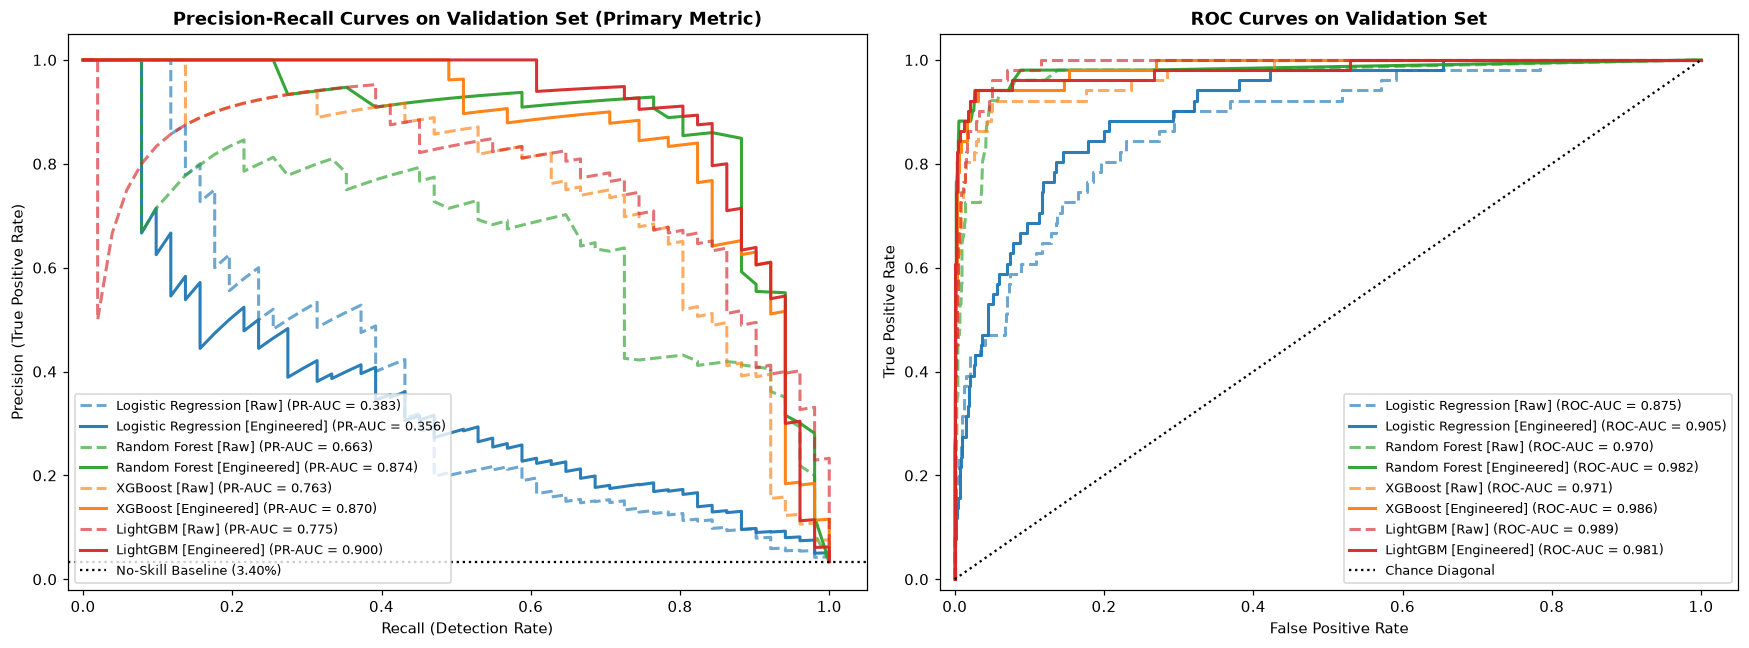

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    'Logistic Regression': '#1f77b4',
    'Random Forest': '#2ca02c',
    'XGBoost': '#ff7f0e',
    'LightGBM': '#d62728'
}

# 1. Precision-Recall Curves
for model_name in models_to_benchmark.keys():
    for fset, style, alpha in [('Raw', '--', 0.65), ('Engineered', '-', 0.95)]:
        prob = validation_probabilities[model_name][fset]
        precision, recall, _ = precision_recall_curve(y_val, prob)
        score = average_precision_score(y_val, prob)
        label = f"{model_name} [{fset}] (PR-AUC = {score:.3f})"
        axes[0].plot(recall, precision, linestyle=style, color=colors[model_name], alpha=alpha, linewidth=2, label=label)

axes[0].axhline(y_val.mean(), color='black', linestyle=':', label=f"No-Skill Baseline ({y_val.mean()*100:.2f}%)")
axes[0].set_title('Precision-Recall Curves on Validation Set (Primary Metric)', fontweight='bold')
axes[0].set_xlabel('Recall (Detection Rate)')
axes[0].set_ylabel('Precision (True Positive Rate)')
axes[0].set_ylim(-0.02, 1.05)
axes[0].set_xlim(-0.02, 1.05)
axes[0].legend(loc='lower left', fontsize=8.5)

# 2. ROC Curves
for model_name in models_to_benchmark.keys():
    for fset, style, alpha in [('Raw', '--', 0.65), ('Engineered', '-', 0.95)]:
        prob = validation_probabilities[model_name][fset]
        fpr, tpr, _ = roc_curve(y_val, prob)
        score = roc_auc_score(y_val, prob)
        label = f"{model_name} [{fset}] (ROC-AUC = {score:.3f})"
        axes[1].plot(fpr, tpr, linestyle=style, color=colors[model_name], alpha=alpha, linewidth=2, label=label)

axes[1].plot([0, 1], [0, 1], color='black', linestyle=':', label='Chance Diagonal')
axes[1].set_title('ROC Curves on Validation Set', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_ylim(-0.02, 1.05)
axes[1].set_xlim(-0.02, 1.05)
axes[1].legend(loc='lower right', fontsize=8.5)

plt.tight_layout()
plt.show()


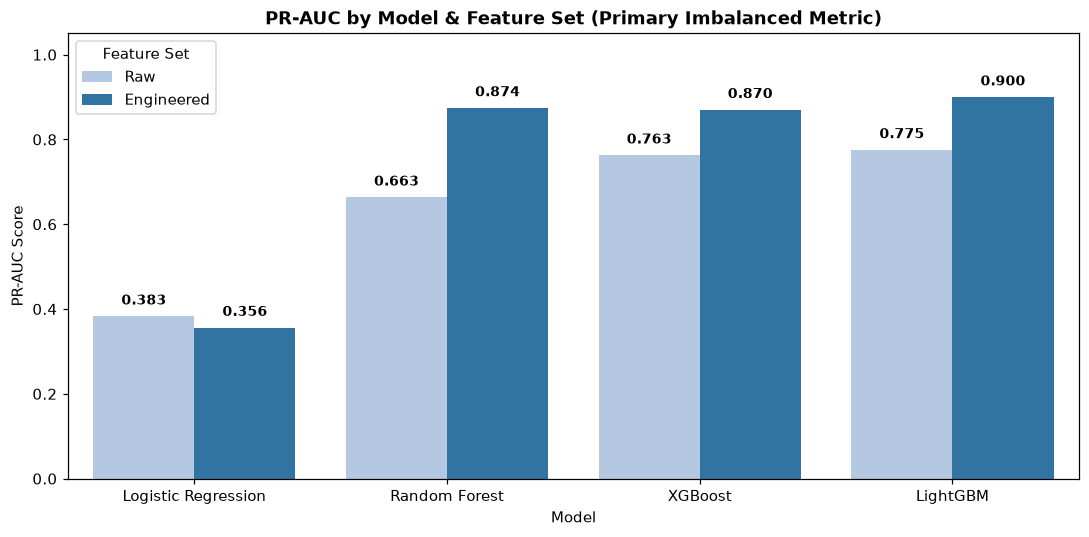

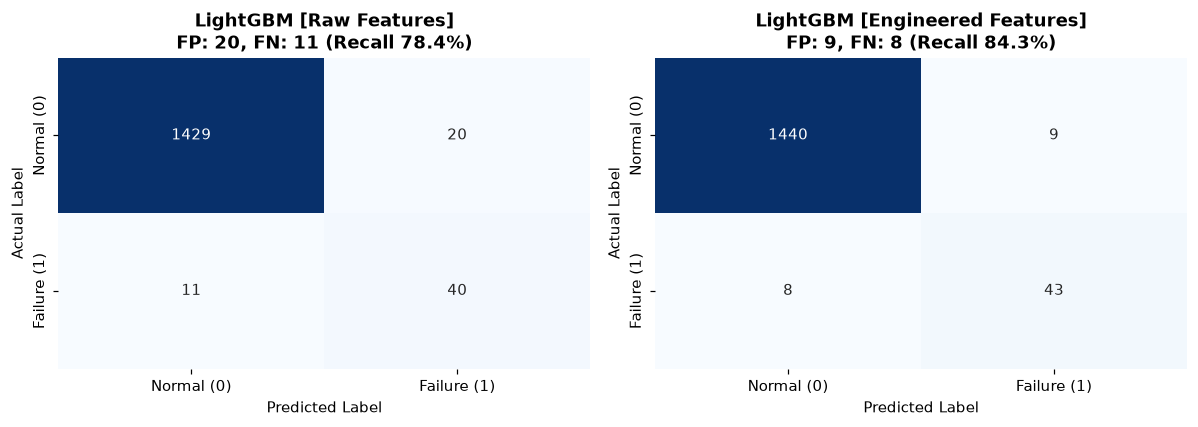

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Bar plot of PR-AUC comparison
sns.barplot(data=benchmark_df, x='Model', y='PR-AUC (Primary)', hue='Feature Set',
            palette=['#aec7e8', '#1f77b4'], ax=axes[0])
axes[0].set_title('PR-AUC by Model & Feature Set (Higher is Better)', fontweight='bold')
axes[0].set_ylabel('PR-AUC Score')
axes[0].set_ylim(0, 1.05)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h + 0.02),
                         ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Confusion matrix comparison for champion model (LightGBM)
lgb_raw_cm = confusion_matrix(y_val, validation_predictions['LightGBM']['Raw'])
lgb_eng_cm = confusion_matrix(y_val, validation_predictions['LightGBM']['Engineered'])

fig_cm, axes_cm = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(lgb_raw_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes_cm[0],
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
axes_cm[0].set_title('LightGBM [Raw Features]\nConfusion Matrix', fontweight='bold')
axes_cm[0].set_xlabel('Predicted')
axes_cm[0].set_ylabel('Actual')

sns.heatmap(lgb_eng_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes_cm[1],
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
axes_cm[1].set_title('LightGBM [Engineered Features]\nConfusion Matrix', fontweight='bold')
axes_cm[1].set_xlabel('Predicted')
axes_cm[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()


### 8. Concise Interpretation & Answers to Core Questions

#### Question 1: Which models perform differently?
1. **Tree Ensembles vs. Linear Models**:
   - The three tree-based architectures (**LightGBM**, **Random Forest**, **XGBoost**) drastically outperform **Logistic Regression**.
   - Under the Engineered feature set:
     - **LightGBM**: PR-AUC = **0.8997**, ROC-AUC = **0.9807**, F1 = **0.8350**
     - **Random Forest**: PR-AUC = **0.8742**, ROC-AUC = **0.9819**, F1 = **0.8454**
     - **XGBoost**: PR-AUC = **0.8699**, ROC-AUC = **0.9856**, F1 = **0.8155**
     - **Logistic Regression**: PR-AUC = **0.3561**, ROC-AUC = **0.9048**, F1 = **0.2787**
   - **Failure Analysis of Logistic Regression**: While Logistic Regression achieves high recall ($78.43\%$), it incurs **196 False Positives**, resulting in a precision of only **$16.95\%$**. A single hyperplane cannot isolate non-linear failure envelopes (e.g., power failures that trigger when power is either $< 3500$ W or $> 9000$ W).

2. **Differences Among Tree Ensembles**:
   - **LightGBM** achieved the highest PR-AUC (**0.8997**) and highest recall (**84.31%**, only 8 missed failures).
   - **Random Forest** achieved the highest precision (**89.13%**, only 5 false alarms) and highest F1-score (**0.8454**).
   - **XGBoost** demonstrated balanced performance with the highest ROC-AUC (**0.9856**) and strong recall (**82.35%**).

---

#### Question 2: Does domain feature engineering improve validation performance?
**Yes, decisively across all non-linear models.**
- **Random Forest**: PR-AUC jumps from **0.6634 to 0.8742 (+0.2108 gain, +31.8% lift)**; F1-score rises from **0.6170 to 0.8454 (+0.2284)**; False Positives plunge from 14 to 5, and False Negatives drop from 22 to 10.
- **LightGBM**: PR-AUC increases from **0.7753 to 0.8997 (+0.1244 gain)**; Recall improves from $78.43\%$ to **$84.31\%$**; False Positives drop by more than half (from 20 down to 9).
- **XGBoost**: PR-AUC increases from **0.7626 to 0.8699 (+0.1073 gain)**; F1-score rises from $0.7170$ to **$0.8155$**.
- **Physical Reason**: While tree models can theoretically approximate non-linear interactions through recursive axis-aligned orthogonal cuts, supplying explicit continuous representations of physical mechanics (such as $\text{Power} = \tau \cdot \omega$ and $\text{WearLoad} = \text{wear} \cdot \tau$) allows the trees to place direct splits on the physical breakdown boundaries with far fewer partition steps.

---

#### Question 3: Which models and feature sets should be carried forward to Phase 5?
1. **Feature Set**:
   - **The Engineered Feature Set (11 features)** is conclusively selected. The empirical lift across all tree algorithms (+10 to +21 percentage points in PR-AUC) makes carrying the raw feature set unnecessary.
2. **Models Carried Forward to Phase 5 (Hyperparameter Optimization & Calibration)**:
   - **Primary Candidate: LightGBM (Engineered)**: Top overall PR-AUC (**0.8997**), top recall (**84.31%**), and fast gradient boosting execution.
   - **Primary Candidate: Random Forest (Engineered)**: Top precision (**89.13%**) and top F1-score (**0.8454**), representing an independent bagging paradigm.
   - **Secondary Candidate: XGBoost (Engineered)**: Robust ensemble contender (PR-AUC **0.8699**, ROC-AUC **0.9856**).
   - **Baseline Reference: Logistic Regression (Engineered)**: Retained strictly as an interpretable linear baseline to quantify the value of non-linear complexity.


### 9. Phase 4 Conclusion & Next Steps

#### Summary of Baseline Benchmarking
- All 8 model-feature configurations were systematically trained strictly on `X_train` and evaluated on `X_val`.
- **Top Validation Model**: **LightGBM [Engineered Features]** achieving **PR-AUC = 0.8997** and **ROC-AUC = 0.9807**.
- **Top Precision Model**: **Random Forest [Engineered Features]** achieving **Precision = 89.13%** and **F1 = 0.8454**.
- Domain feature engineering is empirically validated as an essential component of the predictive pipeline.
- The test set ($N = 1,500$) remains 100% untouched and sealed.

Phase 4 is complete. The benchmark results provide clear empirical justification for hyperparameter optimization and probability calibration in Phase 5.
